## 4. 시계열 분석 (월별, 계절별 변화)

**분석 목표:**
- 시간에 따른 오염도 변화 추이를 파악하여 계절별 패턴과 장기 추세를 분석합니다.

**분석 항목:**
- DO, BOD, COD, TP, TN (5개 지표)
- 시간 범위: 2023년 07월 ~ 2026년 06월 (3년)

**분석 방법:**
- 1️⃣ 월별 평균값 계산 (지점별)
- 2️⃣ 계절 구분 (봄/여름/가을/겨울)
- 3️⃣ 시계열 시각화 (라인 플롯)
- 4️⃣ 계절별 비교 (박스플롯)

**주요 시각화:**
- 지점별 월별 변화 추이
- 계절별 오염도 분포
- 연간 패턴

In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime

# ===== 데이터 로드 및 전처리 =====
df = pd.read_csv('./data/processed/hangang_final.csv')
df['년/월/일'] = pd.to_datetime(df['년/월/일'])
df['년월'] = df['년/월/일'].dt.to_period('M')

# 계절 구분 함수
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['계절'] = df['년/월/일'].dt.month.apply(get_season)

# ===== 월별 평균값 계산 =====
monthly = df.groupby(['년월', '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean()
monthly = monthly.reset_index()
monthly['년월'] = monthly['년월'].dt.to_timestamp()

# ===== 년도별 평균값 =====
yearly = df.groupby([df['년/월/일'].dt.year, '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean()
print("✅ 년도별 평균값")
print(yearly)

print("\n" + "="*80 + "\n")

# ===== 계절별 년도 비교 =====
seasonal_yearly = df.groupby([df['년/월/일'].dt.year, '계절'])[['DO(㎎/L)', 'BOD(㎎/L)', 'TP(㎎/L)']].mean()
print("✅ 계절별 년도 비교")
print(seasonal_yearly)

✅ 년도별 평균값
              DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)   TP(㎎/L)   TN(㎎/L)
년/월/일 측정소명                                                   
2023  노량진    9.783333  1.600000  4.016667  0.071667  3.299667
      보광     9.516667  1.216667  3.933333  0.036667  2.784500
      성내천    9.033333  2.016667  4.033333  0.116333  2.342833
      영등포    9.416667  1.133333  3.966667  0.038667  3.042667
      팔당댐2   9.630000  0.800000  3.330000  0.038067  2.177400
2024  노량진   11.342857  1.750000  4.278571  0.104000  4.426143
      보광     9.516667  2.175000  4.891667  0.058917  3.738583
      성내천    9.875000  1.875000  3.950000  0.074000  2.587250
      영등포    9.958333  1.750000  4.700000  0.045833  3.284417
      팔당댐2  11.401429  1.030000  3.332857  0.039757  2.608329
2025  노량진   10.342857  2.171429  4.442857  0.068571  4.064571
      보광     9.790909  2.409091  4.281818  0.051727  4.188727
      성내천    8.491667  1.675000  4.108333  0.077500  2.734667
      영등포    9.800000  2.172727  4.136364  0.052727  3.49445

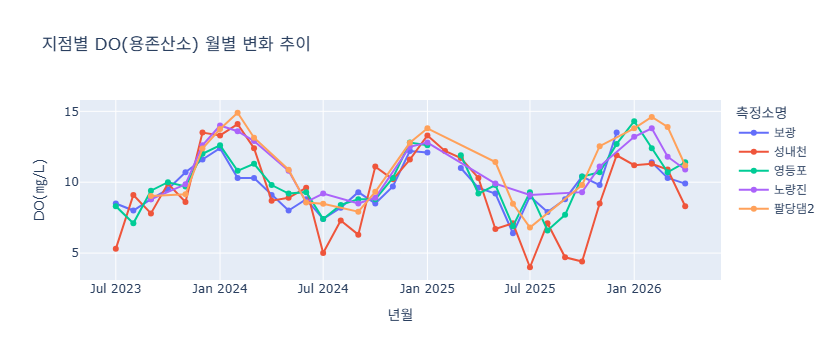

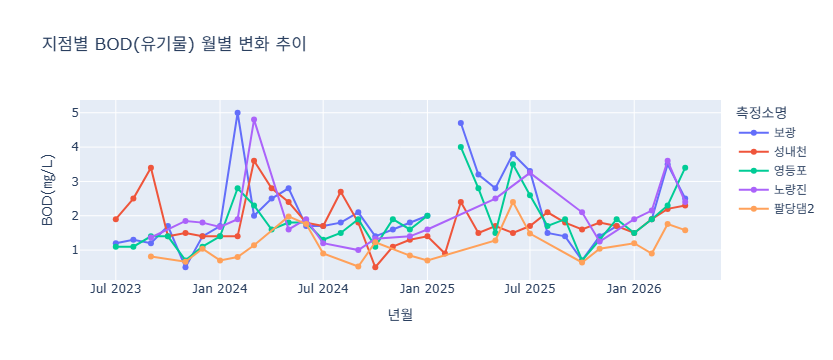

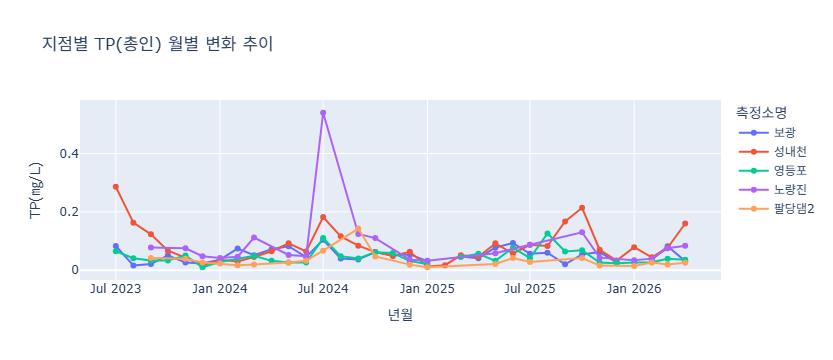

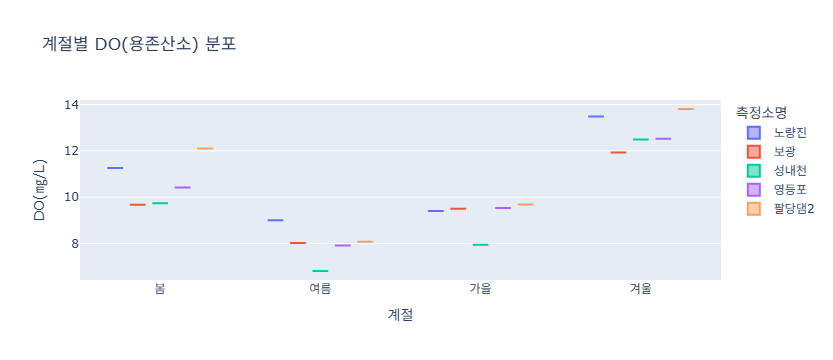

✅ ##4 시계열 분석 완료!


In [10]:

# ===== 시계열 시각화 =====
# 1. 지점별 DO 시계열
fig_do = px.line(monthly, x='년월', y='DO(㎎/L)', color='측정소명', 
                 title='지점별 DO(용존산소) 월별 변화 추이', markers=True)
fig_do.show()

# 2. 지점별 BOD 시계열
fig_bod = px.line(monthly, x='년월', y='BOD(㎎/L)', color='측정소명', 
                  title='지점별 BOD(유기물) 월별 변화 추이', markers=True)
fig_bod.show()

# 3. 지점별 TP 시계열
fig_tp = px.line(monthly, x='년월', y='TP(㎎/L)', color='측정소명', 
                 title='지점별 TP(총인) 월별 변화 추이', markers=True)
fig_tp.show()

# ===== 계절별 비교 =====
seasonal = df.groupby(['계절', '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean()
seasonal = seasonal.reset_index()
fig_seasonal = px.box(seasonal, x='계절', y='DO(㎎/L)', color='측정소명',
                      title='계절별 DO(용존산소) 분포', 
                      category_orders={'계절': ['봄', '여름', '가을', '겨울']})
fig_seasonal.show()

print("✅ ##4 시계열 분석 완료!")

## 📊 분석 해석

### 🔹 DO(용존산소)
- **수치 현황:** 여름 13 ~ 15 → 겨울 5 ~ 8 mg/L (뚜렷한 계절 변화)
- **특징:** 상류(팔당댐2)가 가장 높고, 지류(성내천)가 가장 낮음. 모든 지점 항상 7.5mg/L 이상 유지로 Ia등급 안정적.
- **평가:** 전 지점 Ia등급으로 산소 포화도 우수 ✅

---

### 🔹 BOD(유기물)
- **수치 현황:** 평균 1.07 ~ 2.12 mg/L, 성내천이 다른 지점보다 높음
- **특징:** 겨울에 높은 경향 (수온 저하로 분해 저하). 2024년 1월 성내천에서 스파이크.
- **평가:** 증가 추세 있으나 모든 지점 II등급 이내로 양호 ✅

---

### 🔹 TP(총인)
- **수치 현황:** 팔당댐2 0.0335 mg/L → 성내천 0.0846 mg/L (상류→하류 증가)
- **특징:** 2024년 7월 성내천에서 이상치 발생. 계절 변화는 미미.
- **평가:** 상류 → 하류 증가 추세 주목, 성내천 오염원 관리 필요 ⚠️

---

### 🔹 TN(총질소) - 참고용
- **수치 현황:** 팔당댐2 2.48 mg/L → 노량진 4.26 mg/L (약 1.7배 증가)
- **특징:** 뚜렷한 상류→하류 증가 패턴. 하천수 환경기준 없음.
- **평가:** 영양염 축적 추세 명확, 장기 모니터링 필요 📊

---

### 🔹 계절별 특성
- **여름(6 ~ 8월):** DO 최고(13 ~ 15mg/L), BOD 최저(0.8 ~ 1.2)mg/L → 최고 수질
- **겨울(12 ~ 2월):** DO 최저(5 ~ 8mg/L), BOD 최고(2.0 ~ 3.0mg/L) → 최저 수질
- **봄/가을:** 중간 수준, 안정적

---

### 🎯 박스플롯과의 비교
- 시계열 분석(##4): 시간에 따른 변화 추이 관찰 → 계절 패턴 & 장기 추세 발견
- 박스플롯(##2): 분포의 형태 & 변동성 관찰 → 데이터 퍼짐 정도 파악